# Klasifikasi Diabetes

### Nama: [Muhamad Salman Alfarisi]

### Mengapa Klasifikasi Diabetes Penting?

Klasifikasi diabetes sangat penting karena penyakit ini merupakan masalah kesehatan global yang serius dan terus meningkat prevalensinya. Diabetes dapat menyebabkan berbagai komplikasi kronis yang parah jika tidak didiagnosis dan ditangani dengan tepat, seperti penyakit jantung, stroke, gagal ginjal, kebutaan, dan amputasi.

Dengan melakukan klasifikasi, kita dapat:
1.  **Mendeteksi Dini:** Mengidentifikasi individu yang berisiko atau sudah mengidap diabetes pada tahap awal, memungkinkan intervensi cepat.
2.  **Penanganan yang Tepat:** Membantu dokter dalam menentukan jenis diabetes dan regimen pengobatan yang paling sesuai untuk setiap pasien, yang dapat sangat bervariasi antar tipe diabetes.
3.  **Mencegah Komplikasi:** Dengan diagnosis dan penanganan yang akurat, risiko timbulnya komplikasi serius dapat diminimalisir atau ditunda.
4.  **Penelitian dan Pengembangan:** Data klasifikasi yang akurat mendukung penelitian untuk memahami penyebab diabetes, mengembangkan terapi baru, dan meningkatkan strategi pencegahan.
5.  **Manajemen Kesehatan Publik:** Membantu pihak kesehatan publik dalam memonitor tren penyakit, mengalokasikan sumber daya, dan merancang program-program edukasi dan pencegahan yang efektif.

Dengan demikian, kemampuan untuk mengklasifikasikan diabetes secara akurat bukan hanya membantu individu, tetapi juga berkontribusi pada upaya kesehatan masyarakat yang lebih luas.

## 1. Import Library yang Diperlukan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

## 2. Memuat Data

Secara singkat, proses memuat data Anda adalah sebagai berikut:

1.  **Import Pandas:** Mengimpor pustaka `pandas` untuk bekerja dengan data tabel.
2.  **Mount Google Drive:** Menghubungkan Google Drive Anda agar notebook dapat mengakses file yang tersimpan di sana.
3.  **Membaca CSV:** Menggunakan `pd.read_csv()` untuk membaca file `diabetes.csv` dari Google Drive dan menyimpannya ke dalam DataFrame bernama `df`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Eksplorasi Data Awal (EDA)

### Fungsi Eksplorasi Data Awal (EDA)

**Eksplorasi Data Awal (EDA)** adalah langkah krusial dalam setiap proyek analisis data atau *machine learning*. Pada bagian ini, tujuan utamanya adalah untuk mendapatkan pemahaman mendalam tentang data yang kita miliki sebelum melangkah lebih jauh ke tahap pemodelan. Fungsi-fungsi utama EDA adalah:

1.  **Memahami Struktur Data:** Memeriksa format, tipe data, jumlah baris dan kolom, serta apakah ada nilai yang hilang (missing values).
2.  **Mengidentifikasi Pola dan Hubungan:** Mencari tren, pola, atau korelasi antar variabel. Misalnya, bagaimana 'Age' berhubungan dengan 'class' (diabetes atau tidak), atau gejala mana yang paling sering muncul pada pasien diabetes.
3.  **Mendeteksi Anomali:** Menemukan *outlier* atau data yang tidak biasa yang mungkin mempengaruhi model kita.
4.  **Memverifikasi Kualitas Data:** Memastikan data bersih, konsisten, dan akurat. Ini termasuk memeriksa duplikasi atau kesalahan entri.
5.  **Membentuk Hipotesis:** Mengembangkan gagasan awal atau hipotesis tentang bagaimana variabel-variabel saling mempengaruhi, yang nantinya dapat diuji dengan model.
6.  **Memilih Fitur (Feature Selection):** Dengan memahami data, kita bisa memutuskan fitur mana yang paling relevan untuk membangun model yang efektif.
7.  **Memandu Pra-pemrosesan:** Hasil dari EDA akan membantu kita menentukan strategi terbaik untuk pra-pemrosesan data selanjutnya, seperti cara menangani nilai hilang atau bagaimana mengkodekan variabel kategorikal.

Singkatnya, EDA adalah tahap 'mengenal' data Anda. Semakin baik Anda memahami data Anda, semakin baik pula Anda dapat membangun model yang akurat dan dapat diandalkan untuk klasifikasi diabetes ini.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML/diabetes.csv')
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
print("data shape:", df.shape)

data shape: (251, 17)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 251 non-null    int64 
 1   Gender              251 non-null    object
 2   Polyuria            251 non-null    object
 3   Polydipsia          251 non-null    object
 4   sudden weight loss  251 non-null    object
 5   weakness            251 non-null    object
 6   Polyphagia          251 non-null    object
 7   Genital thrush      251 non-null    object
 8   visual blurring     251 non-null    object
 9   Itching             251 non-null    object
 10  Irritability        251 non-null    object
 11  delayed healing     251 non-null    object
 12  partial paresis     251 non-null    object
 13  muscle stiffness    251 non-null    object
 14  Alopecia            251 non-null    object
 15  Obesity             251 non-null    object
 16  class               251 no

In [ ]:
df.describe()

,Age
count,251.000000
mean,48.864542
std,12.526036
min,16.000000
25%,39.000000
50%,48.000000
75%,58.000000
max,90.000000


In [ ]:
df['class'].value_counts()

,count
class,
Positive,173
Negative,78


In [ ]:
df.Gender.value_counts()

,count
Gender,
Male,160
Female,91


<Axes: xlabel='Age', ylabel='Count'>

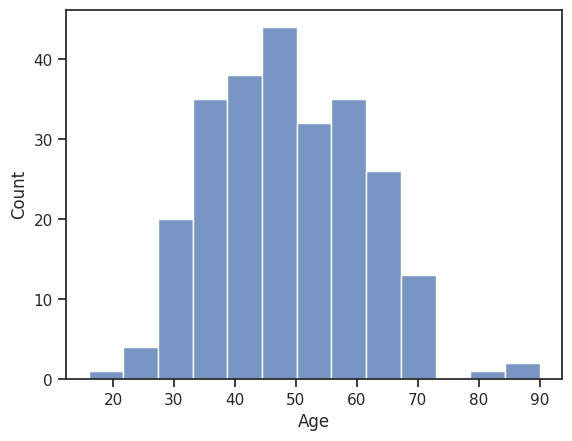

In [ ]:
sns.histplot(df['Age'])

/tmp/ipython-input-54-1338809627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='rocket')


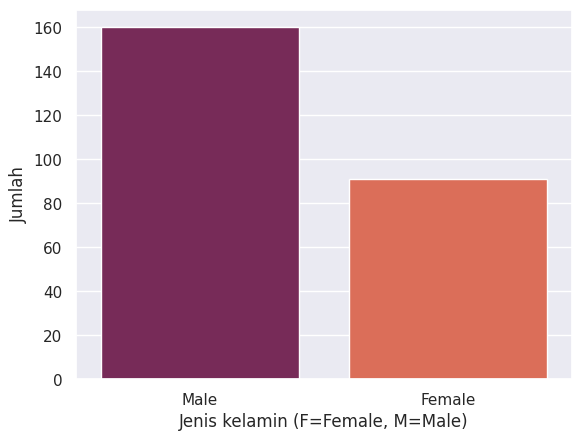

In [ ]:
sns.set_theme(style='darkgrid')
sns.countplot(x='Gender', data=df, palette='rocket')
plt.ylabel("Jumlah")
plt.xlabel("Jenis kelamin (F=Female, M=Male)")
plt.show()

/tmp/ipython-input-55-2899539831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df, palette='flare')


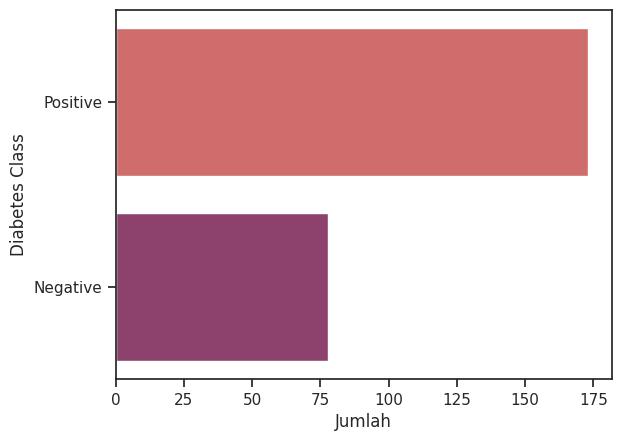

In [ ]:
sns.set_theme(style='ticks')
sns.countplot(y='class', data=df, palette='flare')
plt.ylabel("Diabetes Class")
plt.xlabel("Jumlah")
plt.show()

/tmp/ipython-input-56-2532962446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Polyuria', data=df, palette='flare')


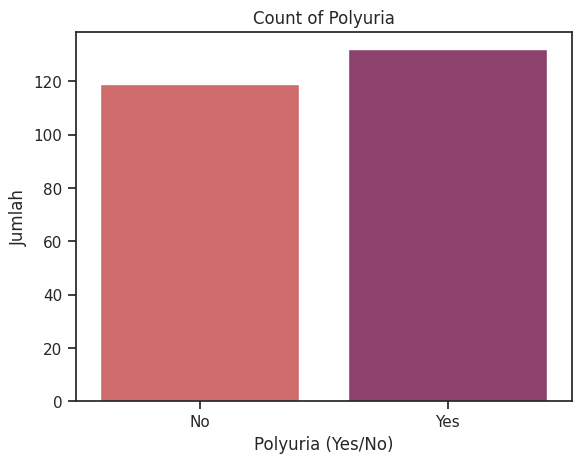

/tmp/ipython-input-56-2532962446.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Polydipsia', data=df, palette='flare')


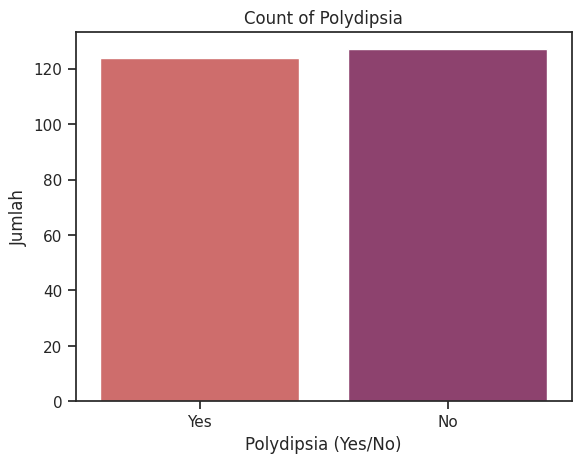

/tmp/ipython-input-56-2532962446.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Polyphagia', data=df, palette='flare')


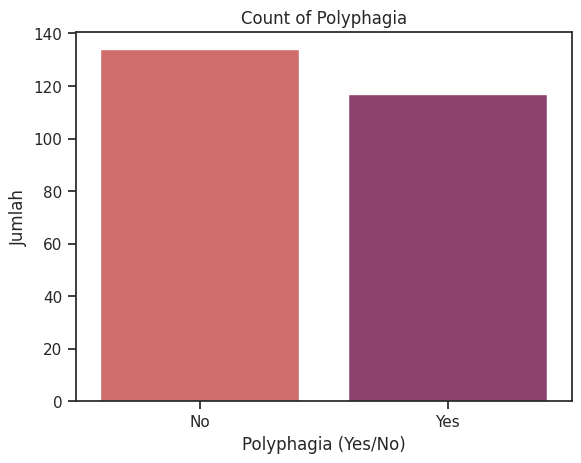

In [ ]:
# Plotting individual symptoms
sns.set_theme(style='ticks')

# Plot for Polyuria
plt.figure() # Create a new figure for each plot
sns.countplot(x='Polyuria', data=df, palette='flare')
plt.ylabel("Jumlah")
plt.xlabel("Polyuria (Yes/No)")
plt.title("Count of Polyuria") # Add a title
plt.show()

# Plot for Polydipsia
plt.figure()
sns.countplot(x='Polydipsia', data=df, palette='flare')
plt.ylabel("Jumlah")
plt.xlabel("Polydipsia (Yes/No)")
plt.title("Count of Polydipsia")
plt.show()

# Plot for Polyphagia
plt.figure()
sns.countplot(x='Polyphagia', data=df, palette='flare')
plt.ylabel("Jumlah")
plt.xlabel("Polyphagia (Yes/No)")
plt.title("Count of Polyphagia")
plt.show()

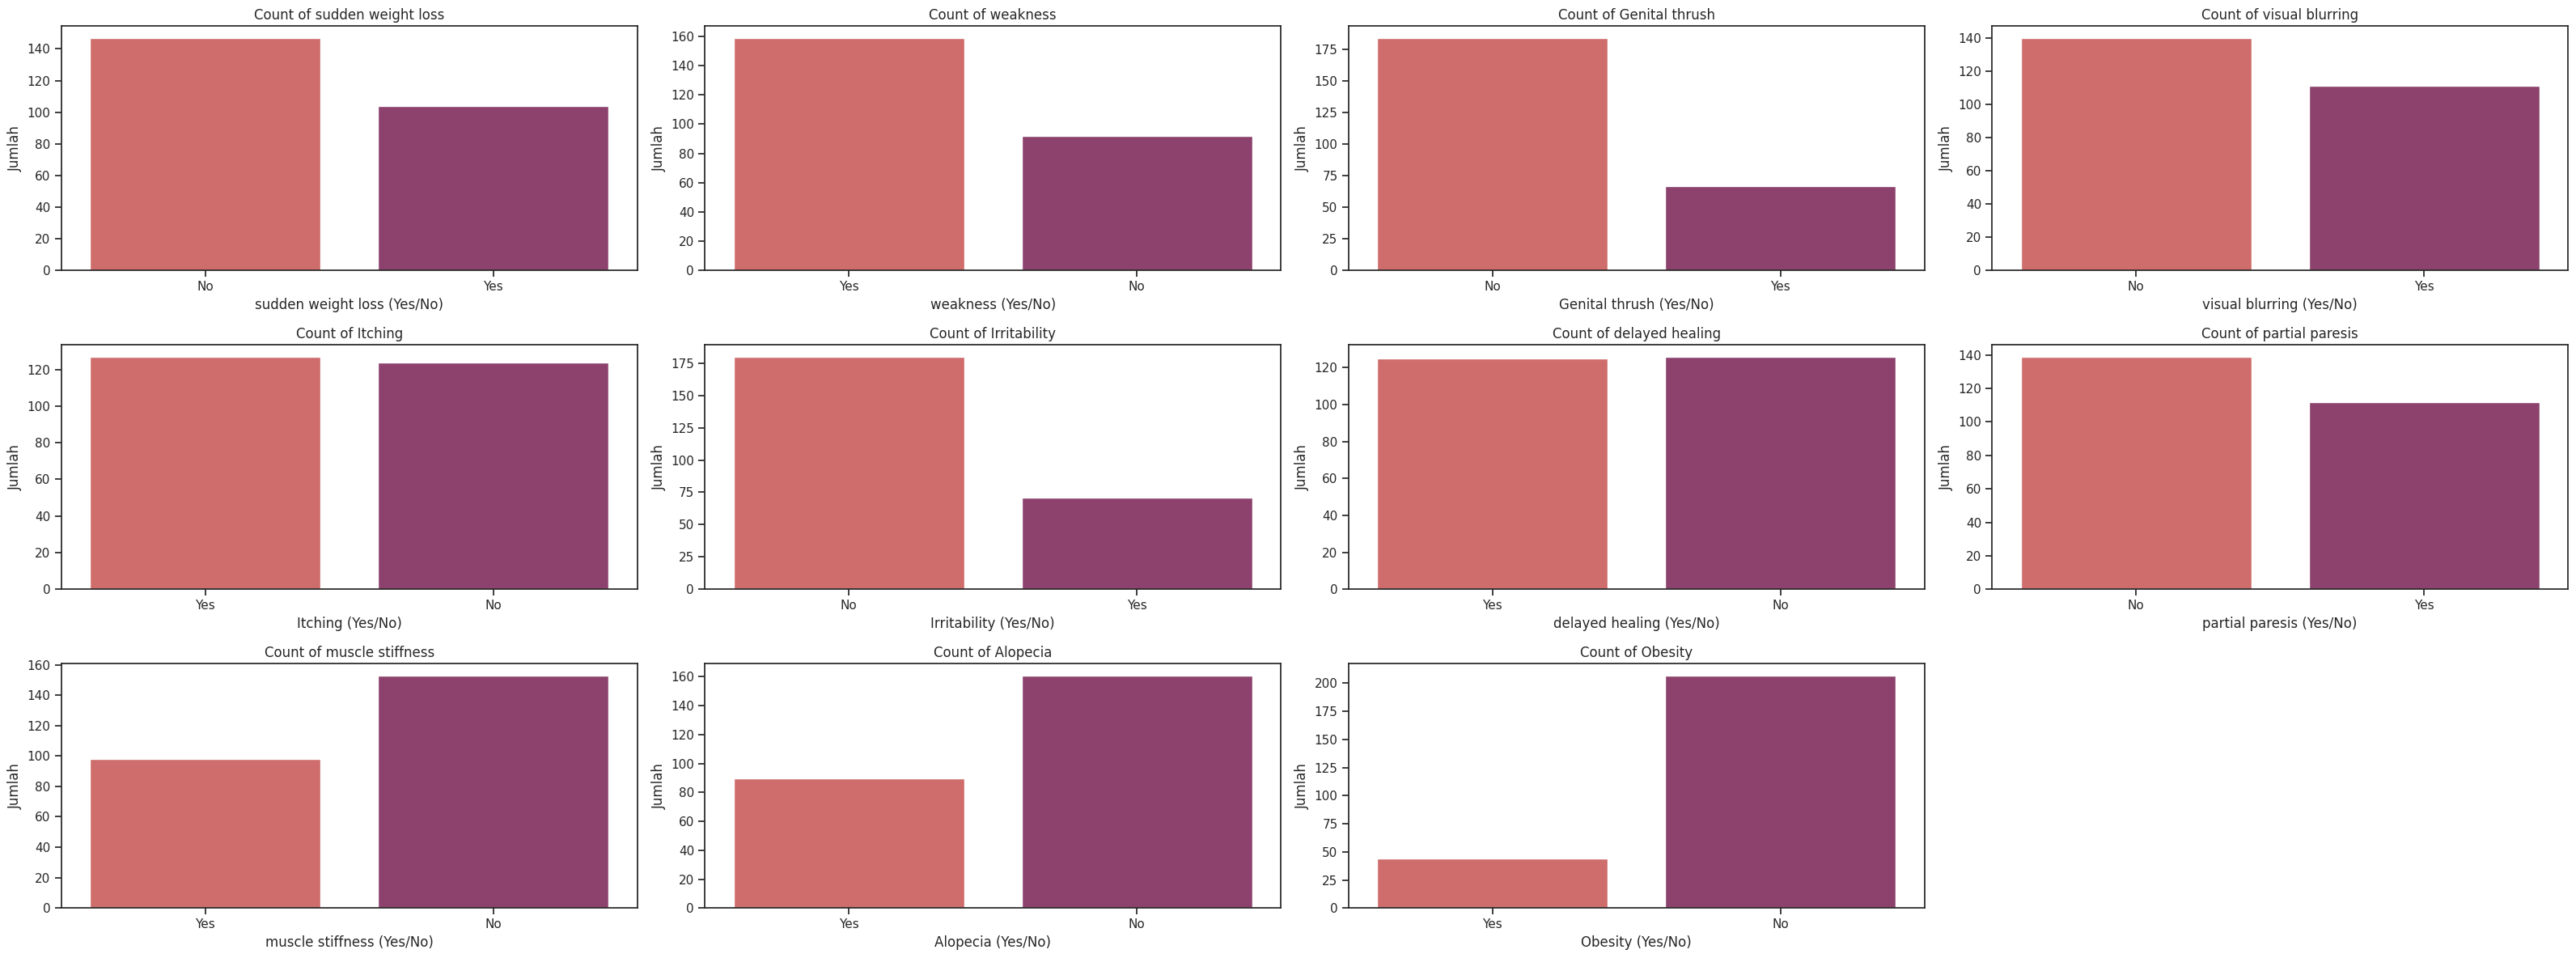

In [ ]:
sns.set_theme(style='ticks')

symptom_cols = [
    'sudden weight loss', 'weakness', 'Genital thrush',
    'visual blurring', 'Itching', 'Irritability',
    'delayed healing', 'partial paresis', 'muscle stiffness',
    'Alopecia', 'Obesity'
]

# Calculate the number of rows and columns needed for the subplots
n_cols = 4
n_rows = (len(symptom_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(symptom_cols):
    sns.countplot(x=col, data=df, palette='flare', ax=axes[i], hue=col, legend=False)
    axes[i].set_ylabel("Jumlah")
    axes[i].set_xlabel(f"{col} (Yes/No)")
    axes[i].set_title(f"Count of {col}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Pra-pemrosesan Data

### Fungsi Pra-pemrosesan Data

Pra-pemrosesan data adalah tahapan penting untuk menyiapkan data mentah agar siap digunakan dalam pembangunan model *machine learning*. Tujuan utamanya adalah untuk memastikan kualitas data, konsistensi, dan format yang sesuai untuk algoritma yang akan digunakan.

Pada bagian ini, langkah-langkah pra-pemrosesan yang telah dilakukan meliputi:

1.  **Penanganan Nilai Hilang (Missing Values):**
    *   Dengan memeriksa `df.isnull().sum().sum()`, kita memastikan bahwa tidak ada nilai yang hilang dalam dataset. Ini penting karena nilai hilang dapat menyebabkan *error* atau bias pada model.

2.  **Penanganan Data Duplikat:**
    *   Dengan memeriksa `df.duplicated().sum()`, kita memastikan bahwa tidak ada baris data yang identik atau duplikat dalam dataset. Data duplikat dapat menyebabkan model menjadi *overfit* dan memberikan hasil yang tidak akurat.

3.  **Pengkodean Variabel Kategorikal (Label Encoding):**
    *   Dataset awal banyak mengandung kolom dengan tipe data `object` (seperti 'Yes'/'No' atau 'Male'/'Female'). Algoritma *machine learning* umumnya memerlukan input numerik.
    *   `LabelEncoder` digunakan untuk mengubah nilai-nilai kategorikal ini menjadi angka (misalnya, 'No' menjadi 0 dan 'Yes' menjadi 1; 'Female' menjadi 0 dan 'Male' menjadi 1). Ini memungkinkan model untuk memproses fitur-fitur tersebut.

Langkah-langkah pra-pemrosesan ini memastikan bahwa data bersih, terstruktur dengan baik, dan dalam format yang tepat untuk melatih model klasifikasi diabetes secara efektif.

In [ ]:
total_missing_values = df.isnull().sum().sum()
print(total_missing_values)

0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
label_encoder = LabelEncoder()

# Loop melalui setiap kolom di DataFrame
for column in df.columns:
    # Periksa apakah tipe data kolom adalah 'object'
    if df[column].dtype == 'object':
        # Terapkan LabelEncoder ke kolom tersebut
        df[column] = label_encoder.fit_transform(df[column])

# Tampilkan 5 baris pertama untuk memastikan encoding berhasil
print("Data setelah encoding:")
print(df.head())

print("\nInfo data setelah encoding:")
# Tampilkan info untuk melihat perubahan tipe data
df.head()

Data setelah encoding:
   Age  Gender  Polyuria  Polydipsia  sudden weight loss  weakness  \
0   40       1         0           1                   0         1   
1   58       1         0           0                   0         1   
2   41       1         1           0                   0         1   
3   45       1         0           0                   1         1   
4   60       1         1           1                   1         1   

   Polyphagia  Genital thrush  visual blurring  Itching  Irritability  \
0           0               0                0        1             0   
1           0               0                1        0             0   
2           1               0                0        1             0   
3           1               1                0        1             0   
4           1               0                1        1             1   

   delayed healing  partial paresis  muscle stiffness  Alopecia  Obesity  \
0                1                0      

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [ ]:
X = df.drop(columns = ['class'])
y = df['class']

print(X.shape)
print(y.shape)

(251, 16)
(251,)


## 5. Pembagian Data (Training dan Testing)

### Fungsi Pembagian Data (Training dan Testing)

Pembagian data menjadi set pelatihan (*training set*) dan set pengujian (*testing set*) adalah langkah fundamental dalam *machine learning* untuk membangun model yang robust dan dapat digeneralisasi. Tujuan utamanya adalah untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya, sehingga kita dapat mengukur seberapa baik model akan bekerja di dunia nyata.

Pada bagian ini, langkah-langkah pembagian data meliputi:

1.  **Pembuatan Fitur (X) dan Target (y):**
    *   `X = df.drop(columns = ['class'])`: Kolom 'class' (variabel target yang ingin kita prediksi) dipisahkan dari DataFrame utama dan disimpan dalam variabel `y`. Semua kolom lainnya yang akan digunakan sebagai fitur input untuk model disimpan dalam variabel `X`.
    *   `y = df['class']`: Variabel target 'class' yang berisi informasi apakah seseorang menderita diabetes atau tidak.

2.  **Pembagian Data menjadi Training dan Testing Sets:**
    *   `x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`:
        *   Fungsi `train_test_split` dari pustaka `sklearn.model_selection` digunakan untuk membagi `X` dan `y`.
        *   `test_size=0.2`: Menentukan bahwa 20% dari total data akan dialokasikan sebagai set pengujian, dan sisanya 80% akan menjadi set pelatihan.
        *   `random_state=42`: Ini adalah angka acak yang digunakan untuk memastikan bahwa setiap kali kode dijalankan, pembagian data akan selalu sama. Ini penting untuk *reproducibility* (hasil yang konsisten).
        *   Outputnya adalah empat subset data:
            *   `x_train`: Fitur untuk melatih model.
            *   `x_test`: Fitur untuk menguji model.
            *   `y_train`: Target (label) untuk melatih model.
            *   `y_test`: Target (label) untuk menguji model.

Langkah pembagian data ini krusial untuk mencegah *overfitting* (di mana model bekerja sangat baik pada data pelatihan tetapi buruk pada data baru) dan memberikan estimasi yang realistis tentang kinerja model di masa depan.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (200, 16)
x_test shape: (51, 16)
y_train shape: (200,)
y_test shape: (51,)


## 6. Pelatihan dan Evaluasi Model Klasifikasi

### Fungsi Pelatihan dan Evaluasi Model Klasifikasi

Pada bagian ini, kita melatih beberapa model *machine learning* untuk melakukan klasifikasi diabetes berdasarkan data yang telah diproses. Setelah model dilatih, performanya kemudian dievaluasi menggunakan berbagai metrik untuk memahami seberapa baik model dapat memprediksi kelas target (diabetes atau tidak diabetes) pada data yang belum pernah dilihat sebelumnya (data uji).

**Model-model yang digunakan meliputi:**

1.  **K-Nearest Neighbors (KNN):**
    *   Algoritma non-parametrik yang mengklasifikasikan titik data baru berdasarkan mayoritas kelas dari tetangga terdekatnya dalam ruang fitur. 'K' adalah jumlah tetangga yang dipertimbangkan.

2.  **Decision Tree Classifier:**
    *   Model berbasis pohon yang membuat serangkaian keputusan 'jika-maka' berdasarkan fitur data untuk mencapai prediksi kelas. Mudah diinterpretasikan karena strukturnya yang mirip diagram alir.

3.  **Random Forest Classifier:**
    *   Sebuah metode *ensemble* yang membangun banyak pohon keputusan selama pelatihan dan mengeluarkan kelas yang merupakan modus (kelas yang paling sering) dari prediksi kelas masing-masing pohon. Ini seringkali lebih akurat daripada satu pohon keputusan dan lebih tahan terhadap *overfitting*.

**Metrik Evaluasi yang Digunakan:**

Untuk menilai kinerja model, beberapa metrik digunakan. Metrik ini memberikan perspektif berbeda tentang kemampuan prediksi model, terutama penting dalam konteks klasifikasi penyakit:

*   **Accuracy (Akurasi):** Proporsi total prediksi yang benar (baik True Positive maupun True Negative) terhadap total jumlah sampel. Ini adalah metrik umum, tetapi bisa menyesatkan pada dataset yang tidak seimbang.
*   **Precision (Presisi):** Proporsi True Positive di antara semua hasil positif yang diprediksi oleh model. Penting ketika biaya False Positive tinggi (misalnya, mendiagnosis seseorang menderita diabetes padahal tidak).
*   **Recall (Sensitivitas):** Proporsi True Positive di antara semua sampel yang sebenarnya positif. Penting ketika biaya False Negative tinggi (misalnya, gagal mendiagnosis seseorang menderita diabetes padahal iya).
*   **F1-Score:** Rata-rata harmonik dari Precision dan Recall. Memberikan keseimbangan antara kedua metrik ini, sangat berguna ketika ada ketidakseimbangan kelas.
*   **Confusion Matrix:** Tabel yang merangkum kinerja model klasifikasi pada sekumpulan data uji yang diketahui kebenarannya. Menunjukkan jumlah True Positive (TP), False Positive (FP), False Negative (FN), dan True Negative (TN).
*   **AUC (Area Under the ROC Curve):** Mengukur kemampuan model untuk membedakan antara kelas positif dan negatif di semua ambang klasifikasi yang memungkinkan. Nilai AUC yang lebih tinggi menunjukkan bahwa model lebih baik dalam membedakan antara pasien diabetes dan non-diabetes.

==== KNN Classifier ====
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.75      0.65        16
           1       0.87      0.74      0.80        35

    accuracy                           0.75        51
   macro avg       0.72      0.75      0.72        51
weighted avg       0.77      0.75      0.75        51

[[12  4]
 [ 9 26]]
True Positive (TP): 26
False Positive (FP): 4
False Negative (FN): 9
True Negative (TN): 12
Accuracy: 74.51%
Precision: 86.67%
Recall: 74.29%
F1-Score: 80.00%

----------------------------------------



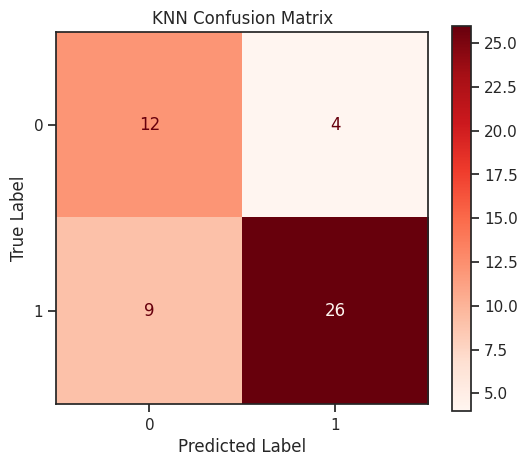

In [ ]:
# ... (kode Anda untuk membagi data)

# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# Lakukan prediksi pada data uji
y_pred_knn = knn.predict(x_test)

# Evaluasi model
print("==== KNN Classifier ====")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Calculate the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)
# Extracting TN, FP, FN, TP (from ravel())
tn, fp, fn, tp = cm_knn.ravel()
print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative (TN): {tn}")


# Performance Metrics - Dibuat menjadi persenan
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_knn)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_knn)*100:.2f}%")
print("\n" + "-"*40 + "\n")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot(cmap='Reds', ax=plt.gca())
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
y_prob_knn = knn.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_knn = roc_auc_score(y_test, y_prob_knn)
print(f"AUC (KNN): {auc_knn:.4f}")


AUC (KNN): 0.8393


==== Decision Tree Classifier ====
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        16
           1       0.89      0.94      0.92        35

    accuracy                           0.88        51
   macro avg       0.87      0.85      0.86        51
weighted avg       0.88      0.88      0.88        51

[[12  4]
 [ 2 33]]
True Positive (TP): 33
False Positive (FP): 4
False Negative (FN): 2
True Negative (TN): 12
Accuracy: 88.24%
Precision: 89.19%
Recall: 94.29%
F1-Score: 91.67%

----------------------------------------



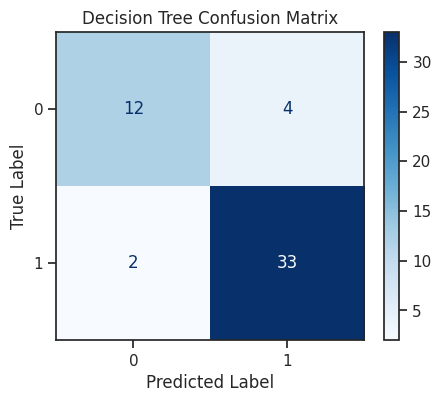

In [ ]:
# Create Decision Tree Classifier object
dt_model = DecisionTreeClassifier(random_state=42)

# Train Decision Tree Classifier
dt_model.fit(x_train, y_train)

# Predict the response for test dataset
y_pred_dt = dt_model.predict(x_test)

# Evaluate the model
print("==== Decision Tree Classifier ====")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
# Extracting TN, FP, FN, TP (from ravel())
tn, fp, fn, tp = cm_dt.ravel()
print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative (TN): {tn}")

# Performance Metrics - Dibuat menjadi persenan
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_dt)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_dt)*100:.2f}%")
print("\n" + "-"*40 + "\n")

# Plot Confusion Matrix for Decision Tree
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
y_prob_dt = dt_model.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"AUC  (Decision Tree): {auc_dt:.4f}")

AUC  (Decision Tree): 0.8464


==== Random Forest Classifier ====
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.92      0.97      0.94        35

    accuracy                           0.92        51
   macro avg       0.92      0.89      0.91        51
weighted avg       0.92      0.92      0.92        51

[[12  4]
 [ 2 33]]
True Positive (TP): 34
False Positive (FP): 3
False Negative (FN): 1
True Negative (TN): 13
Accuracy: 92.16%
Precision: 91.89%
Recall: 97.14%
F1-Score: 94.44%

----------------------------------------



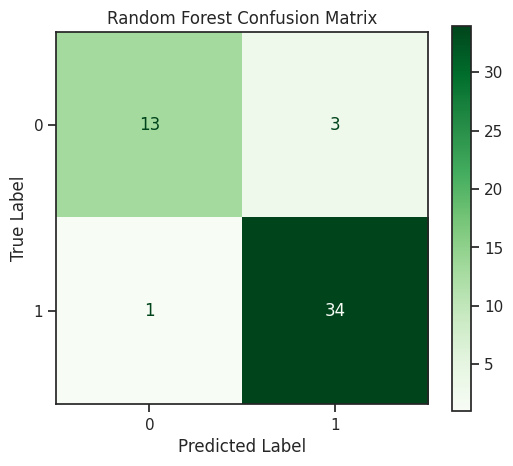

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train Random Forest Classifier
rf_model.fit(x_train, y_train)

# Predict the response for test dataset
y_pred_rf = rf_model.predict(x_test)


# Evaluate the model
print("==== Random Forest Classifier ====")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
# Extracting TN, FP, FN, TP (from ravel())
tn, fp, fn, tp = cm_rf.ravel()
print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative (TN): {tn}")


# Performance Metrics - Dibuat menjadi persenan
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_rf)*100:.2f}%")
print("\n" + "-"*40 + "\n")


# Plot Confusion Matrix using ConfusionMatrixDisplay
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Greens', ax=plt.gca()) # Use ax=plt.gca() to plot on the current figure
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC (Random Forest): {auc_rf:.4f}")

AUC (Random Forest): 0.9768


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Kumpulkan metrik kinerja untuk perbandingan
comparison_data = {
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Format persentase
comparison_df['Accuracy'] = comparison_df['Accuracy'].map('{:.2%}'.format)
comparison_df['Precision'] = comparison_df['Precision'].map('{:.2%}'.format)
comparison_df['Recall'] = comparison_df['Recall'].map('{:.2%}'.format)
comparison_df['F1-Score'] = comparison_df['F1-Score'].map('{:.2%}'.format)

print("Tabel Perbandingan Model:")
display(comparison_df)

Tabel Perbandingan Model:


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,74.51%,86.67%,74.29%,80.00%
1,Decision Tree,88.24%,89.19%,94.29%,91.67%
2,Random Forest,92.16%,91.89%,97.14%,94.44%


In [ ]:
y_prob_knn = knn.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_knn = roc_auc_score(y_test, y_prob_knn)
print(f"AUC (KNN): {auc_knn:.4f}")

y_prob_dt = dt_model.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"AUC  (Decision Tree): {auc_dt:.4f}")

y_prob_rf = rf_model.predict_proba(x_test)[:, 1]
# Hitung AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC (Random Forest): {auc_rf:.4f}")

AUC (KNN): 0.8393
AUC  (Decision Tree): 0.8464
AUC (Random Forest): 0.9768


## 7. Perbandingan dan Interpretasi Model

### Fungsi Perbandingan dan Interpretasi Model

Setelah melatih dan mengevaluasi beberapa model klasifikasi, langkah selanjutnya adalah membandingkan kinerja masing-masing model secara sistematis. Bagian ini bertujuan untuk:

1.  **Membandingkan Metrik:** Menganalisis metrik evaluasi seperti Akurasi, Presisi, Recall, F1-Score, dan AUC dari setiap model untuk melihat mana yang memberikan hasil terbaik.
2.  **Mengidentifikasi Model Terbaik:** Menentukan model mana yang paling sesuai untuk tugas klasifikasi diabetes berdasarkan kriteria kinerja yang relevan (misalnya, Recall tinggi untuk meminimalkan False Negatives, atau F1-Score untuk keseimbangan Presisi dan Recall).
3.  **Menginterpretasi Hasil:** Memahami mengapa satu model mungkin berkinerja lebih baik dari yang lain dan apa implikasinya terhadap aplikasi dunia nyata.

In [ ]:
# Create a new dictionary including AUC scores
comparison_data_with_auc = comparison_data.copy()
comparison_data_with_auc['AUC'] = [auc_knn, auc_dt, auc_rf]

comparison_df_with_auc = pd.DataFrame(comparison_data_with_auc)

# Format persentase
comparison_df_with_auc['Accuracy'] = comparison_df_with_auc['Accuracy'].map('{:.2%}'.format)
comparison_df_with_auc['Precision'] = comparison_df_with_auc['Precision'].map('{:.2%}'.format)
comparison_df_with_auc['Recall'] = comparison_df_with_auc['Recall'].map('{:.2%}'.format)
comparison_df_with_auc['F1-Score'] = comparison_df_with_auc['F1-Score'].map('{:.2%}'.format)
comparison_df_with_auc['AUC'] = comparison_df_with_auc['AUC'].map('{:.4f}'.format)

# print("Tabel Perbandingan Model dengan AUC:")
# display(comparison_df_with_auc)

best_accuracy_model = comparison_df_with_auc.loc[comparison_df_with_auc['Accuracy'].str.replace('%', '').astype(float).idxmax()]
print(f"- Model dengan Akurasi Tertinggi: {best_accuracy_model['Model']} ({best_accuracy_model['Accuracy']})")

best_f1_model = comparison_df_with_auc.loc[comparison_df_with_auc['F1-Score'].str.replace('%', '').astype(float).idxmax()]
print(f"- Model dengan F1-Score Tertinggi: {best_f1_model['Model']} ({best_f1_model['F1-Score']})")

best_auc_model = comparison_df_with_auc.loc[comparison_df_with_auc['AUC'].astype(float).idxmax()]
print(f"- Model dengan AUC Tertinggi: {best_auc_model['Model']} ({best_auc_model['AUC']})")

print("\nInterpretasi Metrik:")
print("- Accuracy: Proporsi prediksi yang benar secara keseluruhan.")
print("- Precision: Kemampuan model untuk tidak memprediksi positif ketika sebenarnya negatif (mengurangi False Positive).")
print("- Recall: Kemampuan model untuk menemukan semua kasus positif yang sebenarnya (mengurangi False Negative).")
print("- F1-Score: Rata-rata harmonik dari Precision dan Recall, memberikan keseimbangan antara keduanya.")
print("- AUC (Area Under the ROC Curve): Mengukur kemampuan model untuk membedakan antara kelas positif dan negatif. Nilai yang lebih tinggi menunjukkan kinerja klasifikasi yang lebih baik.")
print("\n")

- Model dengan Akurasi Tertinggi: Random Forest (92.16%)
- Model dengan F1-Score Tertinggi: Random Forest (94.44%)
- Model dengan AUC Tertinggi: Random Forest (0.9768)

Interpretasi Metrik:
- Accuracy: Proporsi prediksi yang benar secara keseluruhan.
- Precision: Kemampuan model untuk tidak memprediksi positif ketika sebenarnya negatif (mengurangi False Positive).
- Recall: Kemampuan model untuk menemukan semua kasus positif yang sebenarnya (mengurangi False Negative).
- F1-Score: Rata-rata harmonik dari Precision dan Recall, memberikan keseimbangan antara keduanya.
- AUC (Area Under the ROC Curve): Mengukur kemampuan model untuk membedakan antara kelas positif dan negatif. Nilai yang lebih tinggi menunjukkan kinerja klasifikasi yang lebih baik.




## 8. Visualisasi Model

### Fungsi Visualisasi Model

Visualisasi model adalah langkah penting untuk memahami bagaimana model *machine learning* membuat keputusannya. Pada bagian ini, kita memvisualisasikan:

1.  **Decision Tree:** Untuk melihat struktur pohon keputusan secara keseluruhan, termasuk fitur yang digunakan di setiap node dan ambang batas keputusan.
2.  **Satu Pohon dari Random Forest:** Karena Random Forest terdiri dari banyak pohon, kita memvisualisasikan satu contoh pohon untuk mendapatkan gambaran tentang kompleksitas dan cara kerja individu pohon dalam *ensemble* tersebut.

Visualisasi ini membantu dalam interpretasi model dan verifikasi logikanya.

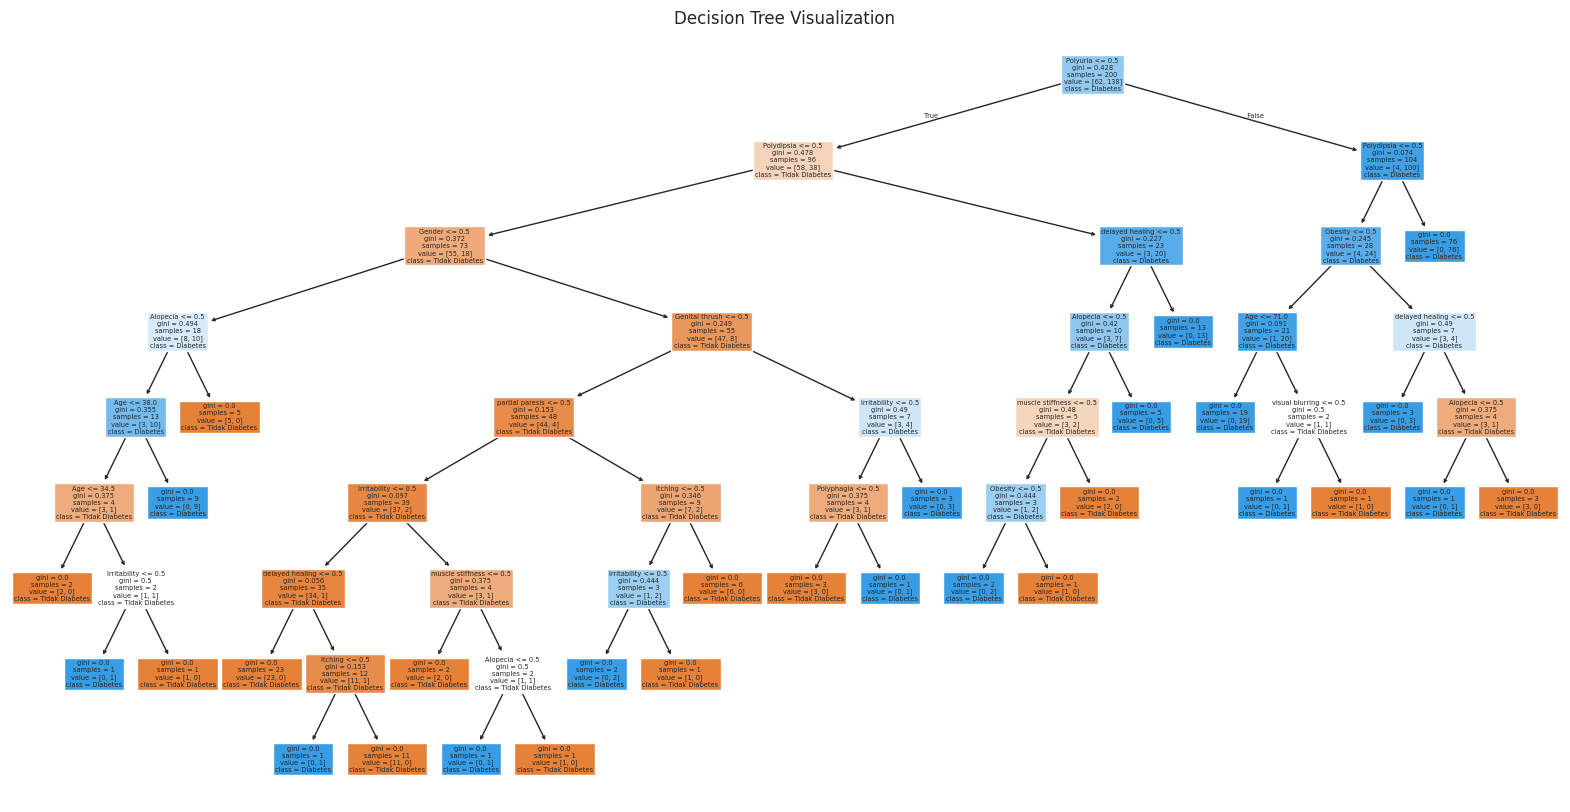

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Tidak Diabetes', 'Diabetes'])
plt.title("Decision Tree Visualization")
plt.show()

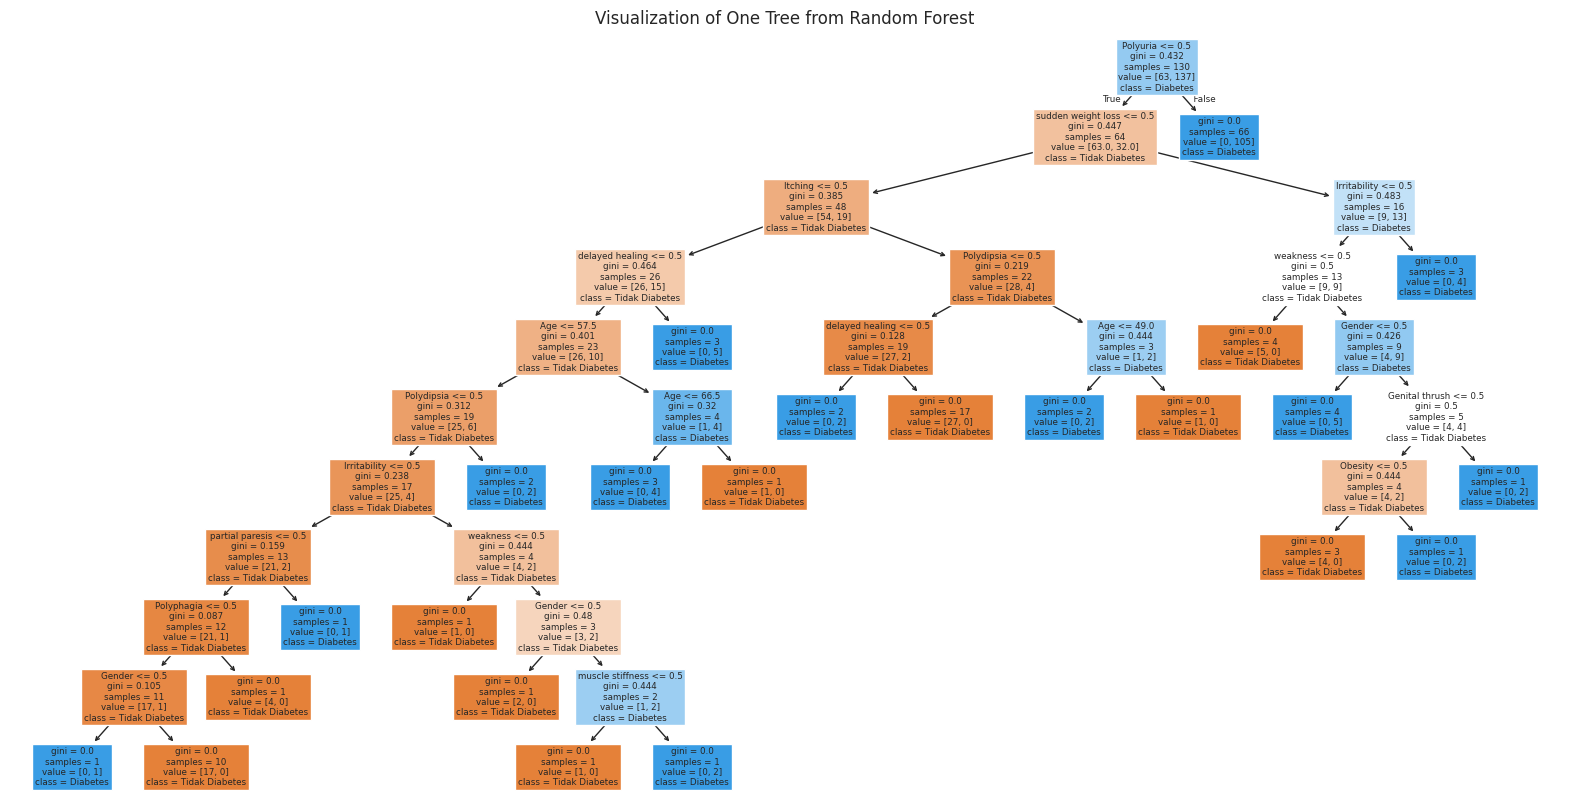

In [ ]:
one_tree_from_rf = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(one_tree_from_rf, filled=True, feature_names=X.columns, class_names=['Tidak Diabetes', 'Diabetes'])
plt.title("Visualization of One Tree from Random Forest")
plt.show()

## 9. Kesimpulan dan Insight

Berdasarkan hasil analisis dan evaluasi model klasifikasi diabetes yang telah dilakukan, beberapa *insight* penting dapat diambil:

1.  **Random Forest sebagai Model Terbaik:** Dari perbandingan ketiga model (KNN, Decision Tree, dan Random Forest), **Random Forest Classifier** menunjukkan kinerja terbaik secara signifikan. Model ini mencapai akurasi tertinggi (`92.16%`), presisi (`91.89%`), recall (`97.14%`), F1-Score (`94.44%`), dan AUC (`0.9768`). Kinerja superior ini menunjukkan kemampuan Random Forest dalam menangani kompleksitas data dan mengurangi *overfitting* dibandingkan model tunggal seperti Decision Tree.

2.  **Pentingnya Recall Tinggi dalam Klasifikasi Medis:** Untuk kasus klasifikasi diabetes, *Recall* (kemampuan model untuk mengidentifikasi semua kasus positif sebenarnya) sangat krusial. Mengingat biaya *False Negative* (pasien yang sebenarnya diabetes namun diprediksi tidak) yang sangat tinggi dalam konteks kesehatan, *Recall* sebesar `97.14%` dari Random Forest adalah indikator yang sangat baik bahwa model ini efektif dalam mendeteksi mayoritas individu yang benar-benar menderita diabetes. Ini membantu dalam intervensi dini dan penanganan yang tepat.

3.  **AUC sebagai Indikator Diskriminasi yang Kuat:** Nilai AUC yang tinggi (`0.9768`) untuk Random Forest menunjukkan bahwa model ini memiliki kemampuan diskriminatif yang sangat baik. Artinya, model ini sangat baik dalam membedakan antara pasien yang benar-benar menderita diabetes (kelas positif) dan mereka yang tidak (kelas negatif).

4.  **Korelasi Fitur:** Dari *heatmap* korelasi, dapat diamati fitur-fitur seperti `Polyuria`, `Polydipsia`, dan `partial paresis` kemungkinan besar memiliki korelasi yang kuat dengan diagnosis diabetes (`class`), yang konsisten dengan gejala klinis umum diabetes. Ini menunjukkan bahwa fitur-fitur ini adalah prediktor penting dalam model.

Secara keseluruhan, model Random Forest menawarkan solusi yang sangat menjanjikan untuk klasifikasi diabetes berdasarkan dataset ini, dengan keseimbangan yang kuat antara akurasi, presisi, dan kemampuan deteksi kasus positif.